## **1. Import Required Libraries**

In [16]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from scipy.stats import chi2_contingency


In [17]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from scipy.stats import chi2_contingency


## **2. Load Dataset**

In [18]:
df = pd.read_csv("Manchester_house_Dataset.csv")

df.head()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800


In [19]:
# price in Thousand
df['price'] = df['price'] / 1_000

#Change Column position
col = df.pop('price')
df.insert(14, 'price', col)
df.head()

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area,price
0,0,7129300520,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340,221.9
1,1,6414100192,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690,538.0
2,2,5631500400,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720,180.0
3,3,2487200875,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360,604.0
4,4,1954400510,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800,510.0


In [20]:
# Change Unites from Square Feet(sqft) to Meter Square(m²)
df['living_area'] = df['living_area'] * 0.092903
df['sqft_living'] = df['sqft_living'] * 0.092903
df['sqft_total'] = df['sqft_total'] * 0.092903
df.head()

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area,price
0,0,7129300520,3.0,1.00,109.62554,524.901950,1.0,0,0,3,7,1955,0,124.49002,221.9
1,1,6414100192,3.0,2.25,238.76071,672.803526,2.0,0,0,3,7,1951,1991,157.00607,538.0
2,2,5631500400,2.0,1.00,71.53531,929.030000,1.0,0,0,3,6,1933,0,252.69616,180.0
3,3,2487200875,4.0,3.00,182.08988,464.515000,1.0,0,0,5,7,1965,0,126.34808,604.0
4,4,1954400510,3.0,2.00,156.07704,750.656240,1.0,0,0,3,8,1987,0,167.22540,510.0


In [21]:
#Renaming the Columns
df.rename(columns={
    'living_area': 'living_area(m²)',
    'sqft_living': 'living_area_internal(m²)',
    'sqft_total': 'total_area(m²)',
    'price': 'price(K£)'
}, inplace=True)
df.head()


,Unnamed: 0,id,bedrooms,bathrooms,living_area_internal(m²),total_area(m²),floors,waterfront,view,condition,grade,built,renovated,living_area(m²),price(K£)
0,0,7129300520,3.0,1.00,109.62554,524.901950,1.0,0,0,3,7,1955,0,124.49002,221.9
1,1,6414100192,3.0,2.25,238.76071,672.803526,2.0,0,0,3,7,1951,1991,157.00607,538.0
2,2,5631500400,2.0,1.00,71.53531,929.030000,1.0,0,0,3,6,1933,0,252.69616,180.0
3,3,2487200875,4.0,3.00,182.08988,464.515000,1.0,0,0,5,7,1965,0,126.34808,604.0
4,4,1954400510,3.0,2.00,156.07704,750.656240,1.0,0,0,3,8,1987,0,167.22540,510.0


In [22]:
# Check dataset size
print(df.shape)

(19999, 15)


In [23]:
#Checking Data Types
df.dtypes

Unnamed: 0                    int64
id                            int64
bedrooms                    float64
bathrooms                   float64
living_area_internal(m²)    float64
total_area(m²)              float64
floors                      float64
waterfront                    int64
view                          int64
condition                     int64
grade                         int64
built                         int64
renovated                     int64
living_area(m²)             float64
price(K£)                   float64
dtype: object

In [24]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                19999 non-null  int64  
 1   id                        19999 non-null  int64  
 2   bedrooms                  19986 non-null  float64
 3   bathrooms                 19989 non-null  float64
 4   living_area_internal(m²)  19999 non-null  float64
 5   total_area(m²)            19999 non-null  float64
 6   floors                    19999 non-null  float64
 7   waterfront                19999 non-null  int64  
 8   view                      19999 non-null  int64  
 9   condition                 19999 non-null  int64  
 10  grade                     19999 non-null  int64  
 11  built                     19999 non-null  int64  
 12  renovated                 19999 non-null  int64  
 13  living_area(m²)           19999 non-null  float64
 14  price(K£)        

# **3. Feature Engineering**

## **5. Data Cleaning**

In [25]:
#Drop Unnecessary Columns
df.drop(['Unnamed: 0', 'id'], axis=1, inplace=True)

#Duplicate Handling
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 4


In [26]:
cols = ['renovated', 'waterfront', 'view']

df[cols] = (df[cols].apply(pd.to_numeric,errors='coerce')
    .fillna(0)
    .ne(0)
    .astype(int)
)

# Preview data
print(df.head())

   bedrooms  bathrooms  living_area_internal(m²)  total_area(m²)  floors  \
0       3.0       1.00                 109.62554      524.901950     1.0   
1       3.0       2.25                 238.76071      672.803526     2.0   
2       2.0       1.00                  71.53531      929.030000     1.0   
3       4.0       3.00                 182.08988      464.515000     1.0   
4       3.0       2.00                 156.07704      750.656240     1.0   

   waterfront  view  condition  grade  built  renovated  living_area(m²)  \
0           0     0          3      7   1955          0        124.49002   
1           0     0          3      7   1951          1        157.00607   
2           0     0          3      6   1933          0        252.69616   
3           0     0          5      7   1965          0        126.34808   
4           0     0          3      8   1987          0        167.22540   

   price(K£)  
0      221.9  
1      538.0  
2      180.0  
3      604.0  
4      510.

In [27]:
#Drop Dublicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19995, 13)


In [28]:
print("Missing Values before Treatment:\n", df.isna().sum())

Missing Values before Treatment:
 bedrooms                    13
bathrooms                   10
living_area_internal(m²)     0
total_area(m²)               0
floors                       0
waterfront                   0
view                         0
condition                    0
grade                        0
built                        0
renovated                    0
living_area(m²)              0
price(K£)                    0
dtype: int64


In [29]:
cols = ['bedrooms', 'bathrooms', 'floors']

for col in cols:
    df[col] = (
        pd.to_numeric(df[col], errors='coerce')  # convert invalid → NaN
        .fillna(df[col].median())                # fill missing with median
        .astype(int)                             # convert to integer
    )

print("Missing Values After Treatment:\n", df.isna().sum())


Missing Values After Treatment:
 bedrooms                    0
bathrooms                   0
living_area_internal(m²)    0
total_area(m²)              0
floors                      0
waterfront                  0
view                        0
condition                   0
grade                       0
built                       0
renovated                   0
living_area(m²)             0
price(K£)                   0
dtype: int64


In [30]:
df.describe()

,bedrooms,bathrooms,living_area_internal(m²),total_area(m²),floors,waterfront,view,condition,grade,built,renovated,living_area(m²),price(K£)
count,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000,19995.000000
mean,3.366442,1.713178,191.187590,1450.153119,1.393898,0.007952,0.101275,3.441810,7.605501,1967.950288,0.045461,183.419594,535.473874
std,0.929873,0.724197,84.142138,3881.025144,0.526370,0.088821,0.301700,0.665496,1.172613,28.315170,0.208319,62.735171,365.987253
min,1.000000,0.000000,26.941870,48.309560,1.000000,0.000000,0.000000,1.000000,1.000000,1900.000000,0.000000,37.068297,75.000000
25%,3.000000,1.000000,131.922260,497.031050,1.000000,0.000000,0.000000,3.000000,7.000000,1950.000000,0.000000,138.425470,317.000000
50%,3.000000,2.000000,176.515700,726.408557,1.000000,0.000000,0.000000,3.000000,7.000000,1969.000000,0.000000,170.012490,449.900000
75%,4.000000,2.000000,233.186530,1022.165258,2.000000,0.000000,0.000000,4.000000,8.000000,1991.000000,0.000000,217.207214,640.000000
max,33.000000,8.000000,1257.906620,153416.205177,3.000000,1.000000,1.000000,5.000000,13.000000,2015.000000,1.000000,576.927630,7700.000000


# **4. Exploratory Data Analysis (EDA)**

In [31]:
# Value Distribution Checks Count 0s and 1sS
binary_counts = df[['renovated', 'waterfront', 'view']].apply(pd.Series.value_counts)
print(binary_counts)

   renovated  waterfront   view
0      19086       19836  17970
1        909         159   2025


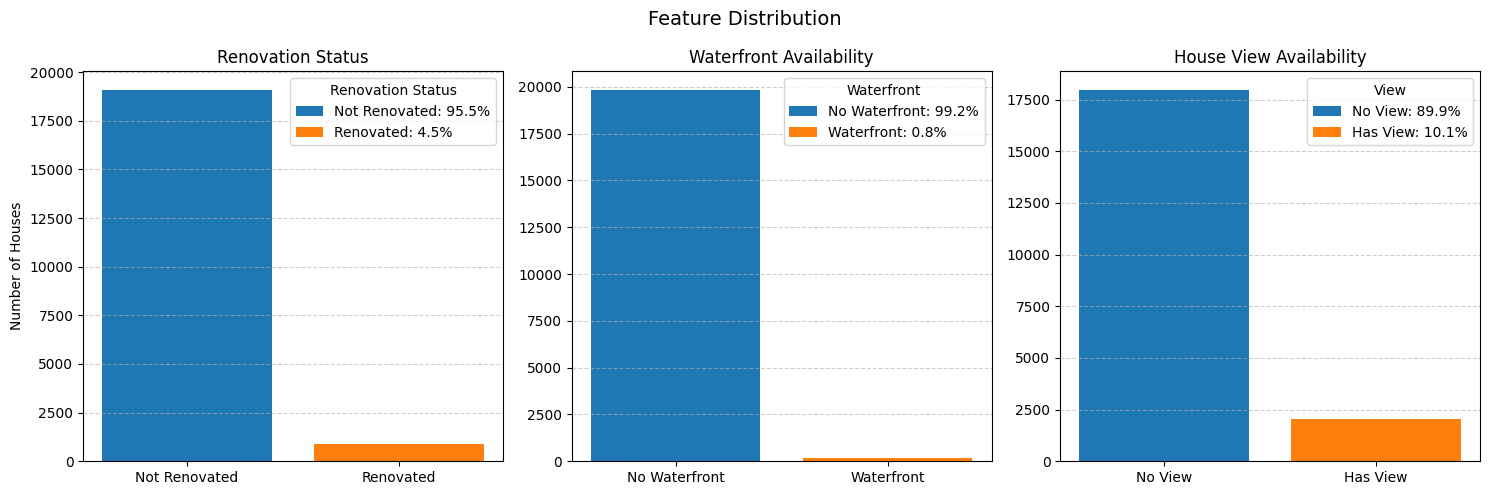

In [32]:
# Counts
renovated_counts = df['renovated'].value_counts().sort_index()
waterfront_counts = df['waterfront'].value_counts().sort_index()
view_counts = df['view'].value_counts().sort_index()

def get_percentages(counts):
    total = counts.sum()
    return (counts / total * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Renovated
renovated_pct = get_percentages(renovated_counts)

bars = axes[0].bar(
    ['Not Renovated', 'Renovated'],
    renovated_counts,
    color=['#1f77b4', '#ff7f0e']
)

axes[0].legend(
    bars,
    [f"Not Renovated: {renovated_pct[0]}%",
     f"Renovated: {renovated_pct[1]}%"],
    title="Renovation Status"
)

axes[0].set_title('Renovation Status')
axes[0].set_ylabel('Number of Houses')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)


# Waterfront
waterfront_pct = get_percentages(waterfront_counts)

bars = axes[1].bar(
    ['No Waterfront', 'Waterfront'],
    waterfront_counts,
    color=['#1f77b4', '#ff7f0e']
)

axes[1].legend(
    bars,
    [f"No Waterfront: {waterfront_pct[0]}%",
     f"Waterfront: {waterfront_pct[1]}%"],
    title="Waterfront"
)

axes[1].set_title('Waterfront Availability')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)


# View
view_pct = get_percentages(view_counts)

bars = axes[2].bar(
    ['No View', 'Has View'],
    view_counts,
    color=['#1f77b4', '#ff7f0e']
)

axes[2].legend(
    bars,
    [f"No View: {view_pct[0]}%",
     f"Has View: {view_pct[1]}%"],
    title="View"
)

axes[2].set_title('House View Availability')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

# Layout
plt.suptitle('Feature Distribution', fontsize=14)
plt.tight_layout()
plt.savefig("Feature Distribution.png", dpi=1000)
plt.show()



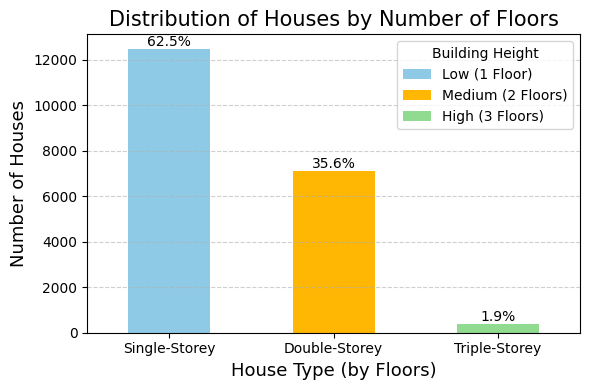

In [33]:
floor_counts = df['floors'].value_counts().sort_index()
floor_pct = (floor_counts / floor_counts.sum() * 100).round(1)

# Plot bar chart
ax = floor_counts.plot(
    kind='bar',
    color = ['#8ecae6', '#ffb703', '#90db90'],
    figsize=(6, 4)
)

# Meaningful x-axis labels
ax.set_xticklabels(
    ['Single-Storey', 'Double-Storey', 'Triple-Storey'],
    rotation=0
)

# Add percentage above bars
for i, value in enumerate(floor_counts):
    ax.text(
        i,
        value,
        f"{floor_pct.iloc[i]}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

# legend (one label per bar)
bars = ax.patches
ax.legend(
    bars,
    ['Low (1 Floor)', 'Medium (2 Floors)', 'High (3 Floors)'],
    title='Building Height'
)

plt.title("Distribution of Houses by Number of Floors", fontsize=15)
plt.xlabel("House Type (by Floors)",fontsize=13)
plt.ylabel("Number of Houses",fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Distribution_of_Houses_by_Floors.png", dpi=1000)
plt.show()




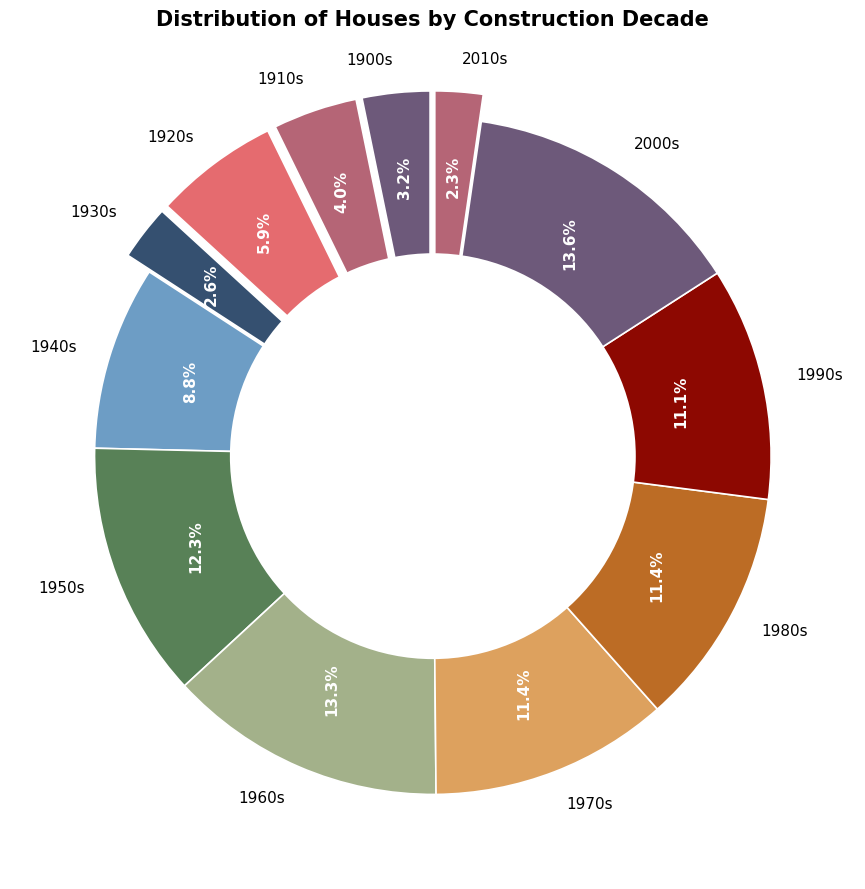

In [34]:
# Create decade column
df['built_decade'] = (df['built'] // 10) * 10

# Count houses per decade
built_counts = df['built_decade'].value_counts().sort_index()

# Explode small slices slightly
explode = []

for v in built_counts:
    if v < built_counts.mean():
        explode.append(0.08)
    else:
        explode.append(0)


# Slightly dark colors
colors = [
    '#6d597a', '#b56576', '#e56b6f',
    '#355070', '#6d9dc5',
    '#588157', '#a3b18a',
    '#dda15e', '#bc6c25', '#8d0801'
]

plt.figure(figsize=(9, 9))

# Donut chart
wedges, texts, autotexts = plt.pie(
    built_counts,
    labels=[f"{d}s" for d in built_counts.index],  # ✅ YEAR labels
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(built_counts)],
    explode=explode,
    pctdistance=0.75,        # percentage inside
    labeldistance=1.10,      # year outside
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 11}
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_rotation(90)
    autotext.set_fontweight('bold')

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)


# Title
plt.title(
    "Distribution of Houses by Construction Decade",
    fontsize=15,
    weight='bold'
)

plt.tight_layout()
plt.savefig("Donut_Chart_Houses_by_Build_Decade_With_Years.png", dpi=1000)
plt.show()



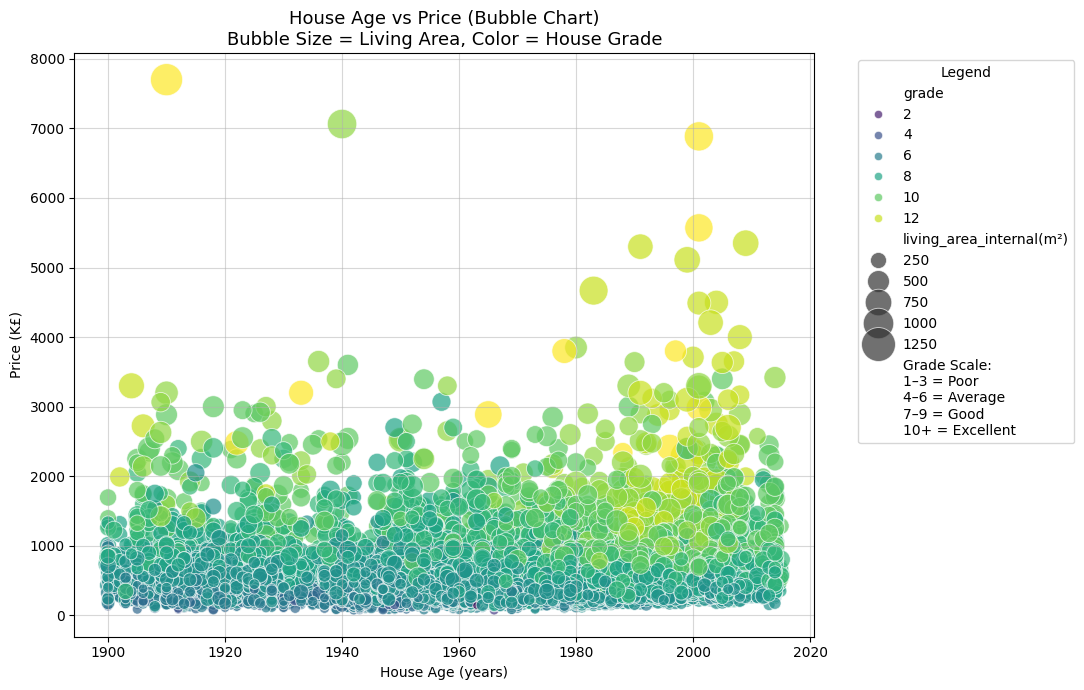

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

plt.figure(figsize=(11, 7))

sns.scatterplot(
    x='built',
    y='price(K£)',
    size='living_area_internal(m²)',   # bubble size
    hue='grade',                       # color by grade
    sizes=(30, 600),
    alpha=0.7,
    palette='viridis',
    data=df
)

plt.title(
    "House Age vs Price (Bubble Chart)\n"
    "Bubble Size = Living Area, Color = House Grade",
    fontsize=13
)
plt.xlabel("House Age (years)")
plt.ylabel("Price (K£)")

# -------- Custom legend note for grade scale --------
grade_note = Line2D(
    [], [], color='none',
    label=(
        "Grade Scale:\n"
        "1–3 = Poor\n"
        "4–6 = Average\n"
        "7–9 = Good\n"
        "10+ = Excellent"
    )
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(grade_note)

plt.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Legend"
)

plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig("House_Age_vs_Price_Colorful_Bubble.png", dpi=1000)
plt.show()




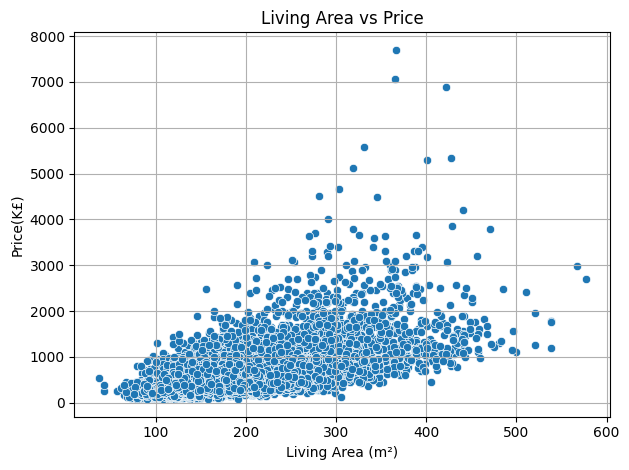

In [36]:
sns.scatterplot(x='living_area(m²)', y='price(K£)', data=df)
plt.title("Living Area vs Price")
plt.xlabel("Living Area (m²)")
plt.ylabel("Price(K£)")
plt.tight_layout()
plt.savefig("Living Area vs Price Scatter Plot.png", dpi=1000)
plt.grid()
plt.show()


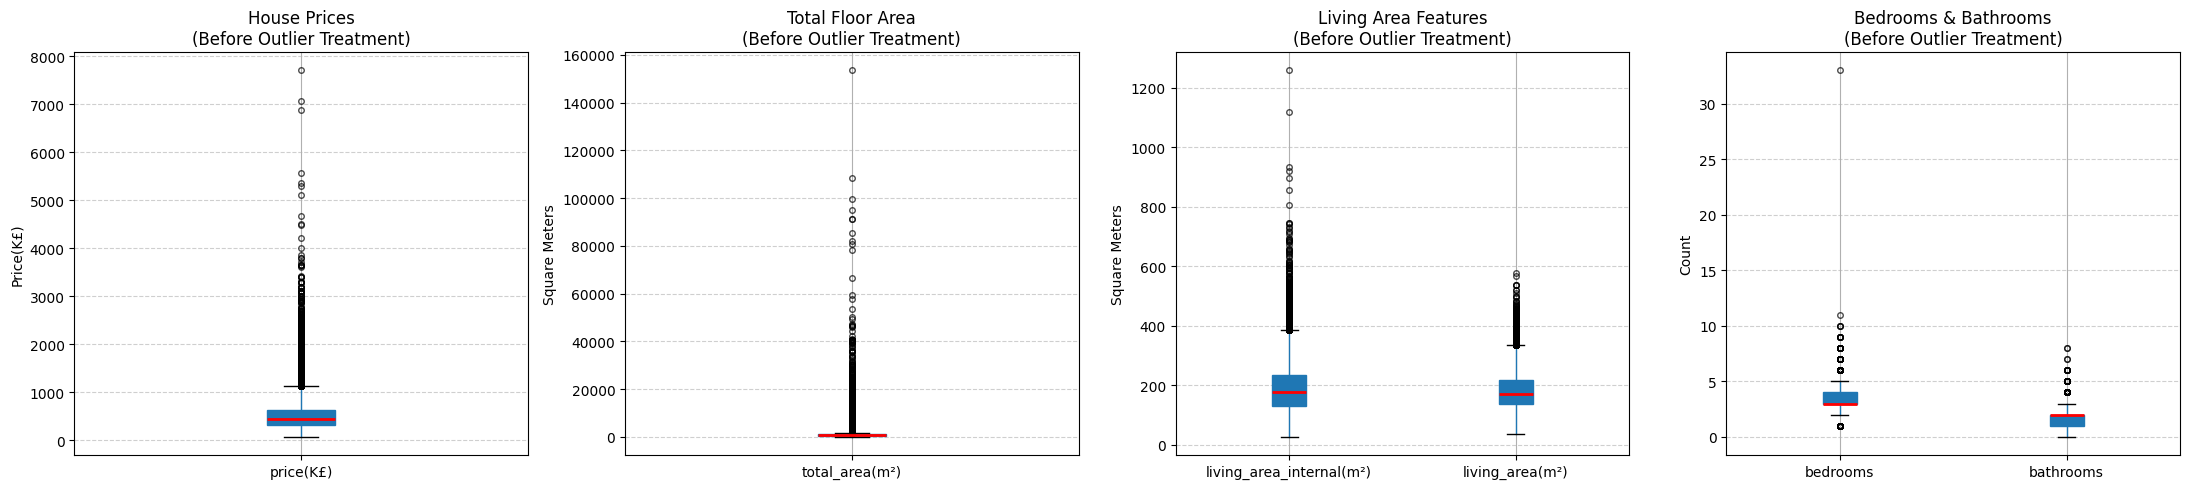

In [37]:
#Checking For Outliers bz BoxPlot
plt.figure(figsize=(22, 5))

# Common boxplot style
box_style = dict(
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.7)
)


# 1. Price
plt.subplot(1, 4, 1)
df_before=df[['price(K£)']].boxplot(**box_style)
plt.title('House Prices\n(Before Outlier Treatment)')
plt.ylabel('Price(K£)')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 2. Total Floor Area
plt.subplot(1, 4, 2)
df[['total_area(m²)']].boxplot(**box_style)
plt.title('Total Floor Area\n(Before Outlier Treatment)')
plt.ylabel('Square Meters')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 3. Living Area Features
plt.subplot(1, 4, 3)
df[['living_area_internal(m²)', 'living_area(m²)']].boxplot(**box_style)
plt.title('Living Area Features\n(Before Outlier Treatment)')
plt.ylabel('Square Meters')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 4. Bedrooms & Bathrooms
plt.subplot(1, 4, 4)
df[['bedrooms', 'bathrooms']].boxplot(**box_style)
plt.title('Bedrooms & Bathrooms\n(Before Outlier Treatment)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig("Before_Outlier_Treatment_Boxplots.png", dpi=1000)
plt.show()


In [38]:
# OUTLIER REMOVAL USING IQR METHOD (CAPPING)


# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Apply IQR capping to each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)


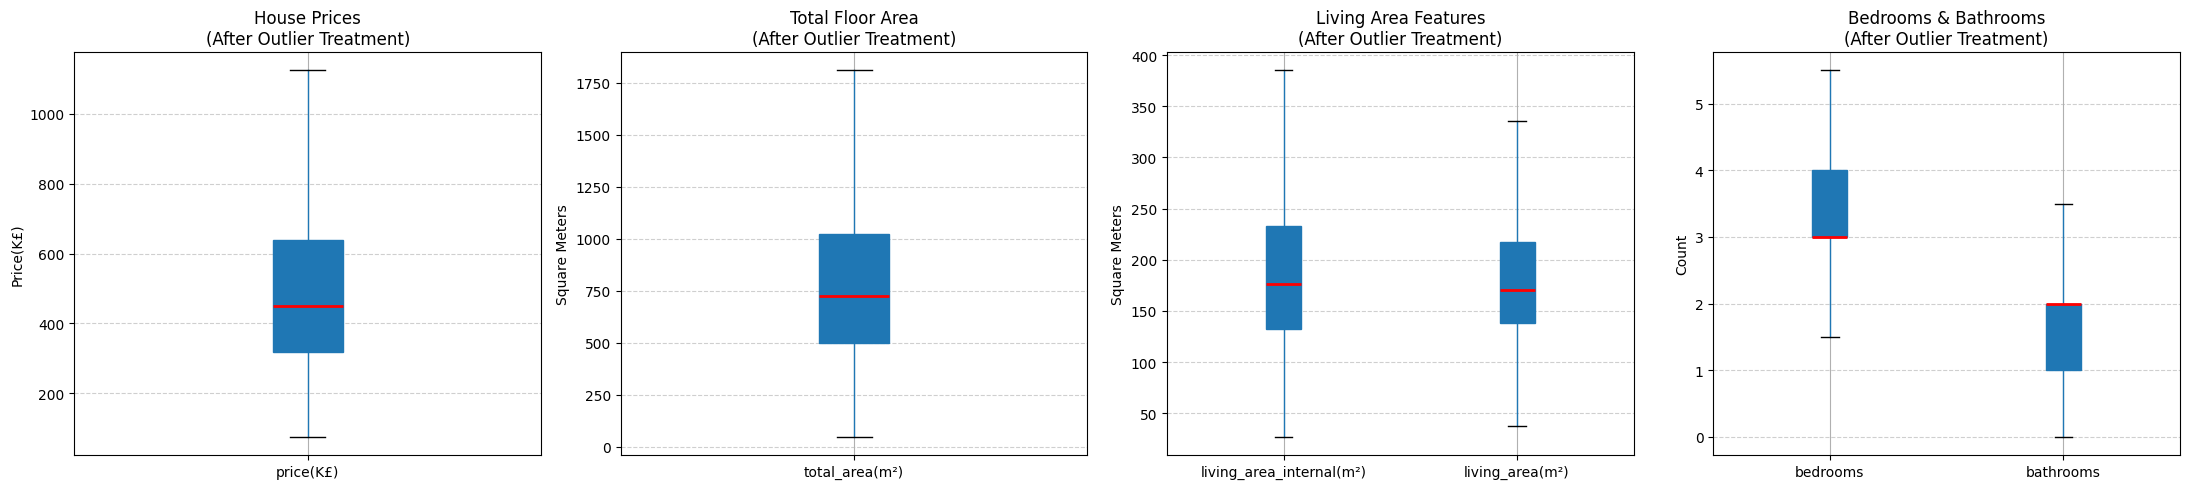

In [39]:
# Checking Outliers after IQR Treatement
plt.figure(figsize=(22, 5))

# Common boxplot style
box_style = dict(patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markersize=4, alpha=0.7))

# 1. Price
plt.subplot(1, 4, 1)
df_after = df[['price(K£)']].boxplot(**box_style)
plt.title('House Prices\n(After Outlier Treatment)')
plt.ylabel('Price(K£)')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 2. Total Floor Area
plt.subplot(1, 4, 2)
df[['total_area(m²)']].boxplot(**box_style)
plt.title('Total Floor Area\n(After Outlier Treatment)')
plt.ylabel('Square Meters')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 3. Living Area Features
plt.subplot(1, 4, 3)
df[['living_area_internal(m²)', 'living_area(m²)']].boxplot(**box_style)
plt.title('Living Area Features\n(After Outlier Treatment)')
plt.ylabel('Square Meters')
plt.grid(axis='y', linestyle='--', alpha=0.6)


# 4. Bedrooms & Bathrooms
plt.subplot(1, 4, 4)
df[['bedrooms', 'bathrooms']].boxplot(**box_style)
plt.title('Bedrooms & Bathrooms\n(After Outlier Treatment)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("After_Outlier_Treatment_Boxplots.png", dpi=1000)
plt.show()



C:\Users\hiten\AppData\Local\Temp\ipykernel_4408\1475906040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


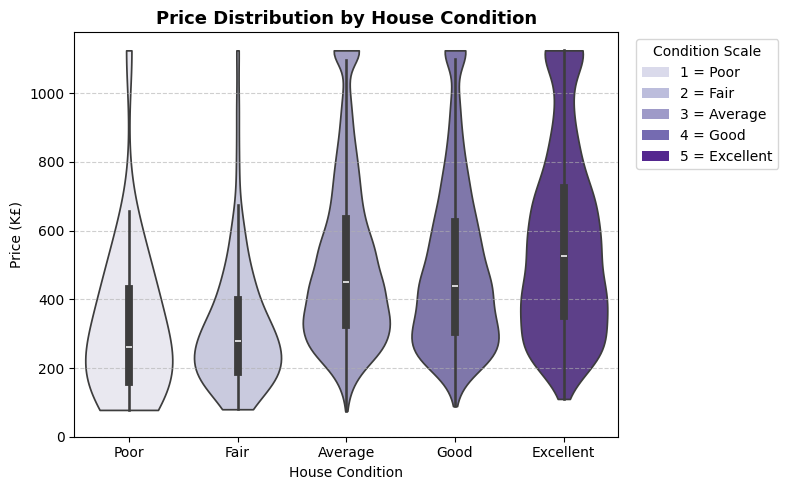

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# Ensure condition is integer
df['condition'] = np.floor(df['condition']).astype(int)

plt.figure(figsize=(8, 5))

# Violin plot
sns.violinplot(
    x='condition',
    y='price(K£)',
    data=df,
    palette='Purples',
    cut=0   # prevents negative extension
)

plt.ylim(bottom=0)   # ensures y-axis starts at 0

plt.xlabel('House Condition')
plt.ylabel('Price (K£)')
plt.title('Price Distribution by House Condition',
          fontsize=13, weight='bold')

plt.xticks(
    [0, 1, 2, 3, 4],
    ['Poor', 'Fair', 'Average', 'Good', 'Excellent']
)

# Custom Legend
legend_elements = [
    Patch(facecolor='#dadaeb', label='1 = Poor'),
    Patch(facecolor='#bcbddc', label='2 = Fair'),
    Patch(facecolor='#9e9ac8', label='3 = Average'),
    Patch(facecolor='#756bb1', label='4 = Good'),
    Patch(facecolor='#54278f', label='5 = Excellent')
]

plt.legend(
    handles=legend_elements,
    title="Condition Scale",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Price_by_Condition_Violin_Final.png", dpi=1000)
plt.show()

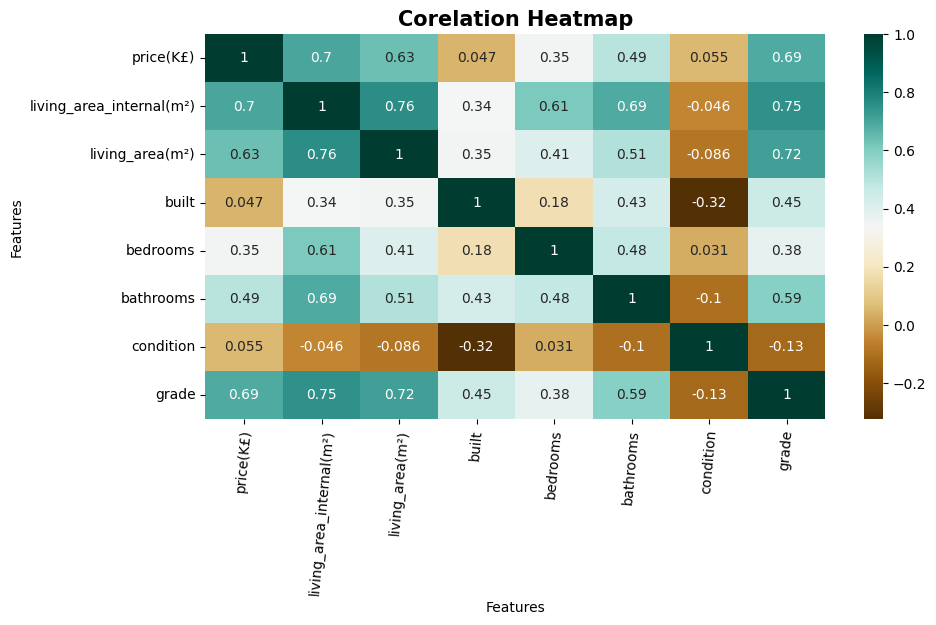

In [41]:
# Find Corelation using Heatmap
corr_cols = [
    'price(K£)',
    'living_area_internal(m²)',
    'living_area(m²)',
    'built',
    'bedrooms',
    'bathrooms',
    'condition',
    'grade'
]

plt.figure(figsize=(10,5))

corr = df[corr_cols].corr()   # store correlation

sns.heatmap(corr, cmap="BrBG", annot=True)
plt.title("Corelation Heatmap", fontsize=15, weight='bold')
plt.xlabel("Features")
plt.xticks(rotation=85)
plt.ylabel("Features")
plt.savefig("Corelation Heatmap.png", dpi=1000, bbox_inches='tight')
plt.show()


In [42]:
# Z-score for numerical columns
z_scores = df[['price(K£)', 'living_area(m²)','living_area_internal(m²)', 'total_area(m²)']].apply(zscore)

# Add to dataframe
df[['price_z', 'living_area_z','sqft_living_z', 'sqft_total_z']] = z_scores

z_scores.head()


,price(K£),living_area(m²),living_area_internal(m²),total_area(m²)
0,-1.145522,-0.976461,-1.040178,-0.668342
1,0.122887,-0.427256,0.651181,-0.354476
2,-1.313653,1.188975,-1.539068,0.189269
3,0.387724,-0.945078,-0.091070,-0.796491
4,0.010532,-0.254649,-0.431775,-0.189263


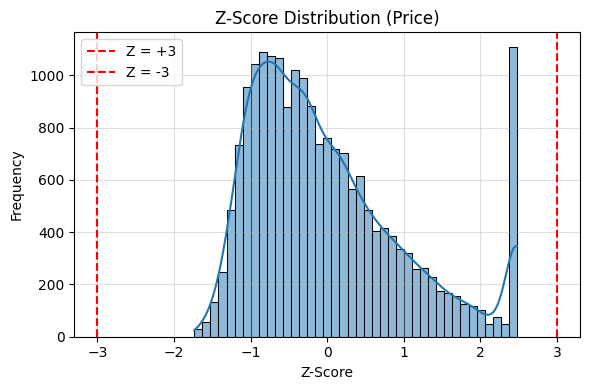

In [43]:
from scipy.stats import zscore

# Z-score calculation
df['price_z'] = zscore(df['price(K£)'])

# Z-score visualization
plt.figure(figsize=(6,4))
sns.histplot(df['price_z'], bins=40, kde=True)
plt.axvline(3, color='red', linestyle='--', label='Z = +3')
plt.axvline(-3, color='red', linestyle='--', label='Z = -3')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.title('Z-Score Distribution (Price)')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("Z-Score Test Distribution")
plt.show()

In [44]:
# T-score from Z-score
t_scores = 50 + 10 * z_scores

# Add to dataframe
df[['price_t', 'living_area(m²)_t','living_area_internal(m²)_t', 'total_area(m²)_t']] = t_scores
t_scores.head()


,price(K£),living_area(m²),living_area_internal(m²),total_area(m²)
0,38.544784,40.235391,39.598222,43.316578
1,51.228872,45.727440,56.511810,46.455239
2,36.863470,61.889755,34.609322,51.892694
3,53.877242,40.549223,49.089300,42.035089
4,50.105321,47.453512,45.682246,48.107374


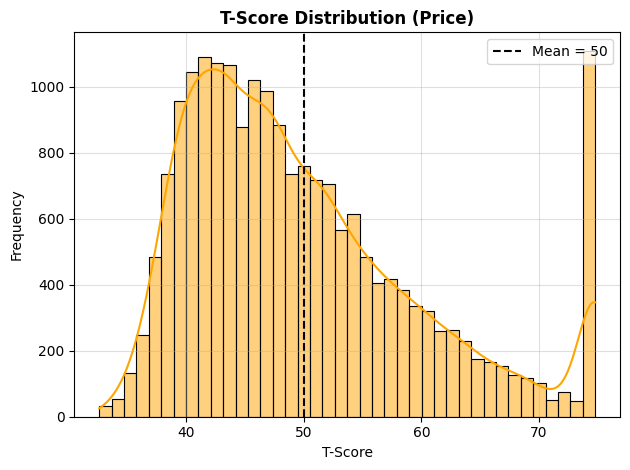

In [45]:
#T-Score Visualization

sns.histplot(
    df['price_t'],
    kde=True,
    bins=40,
    color='orange'
)

plt.axvline(50, color='black', linestyle='--', label='Mean = 50')
plt.title('T-Score Distribution (Price)', fontsize=12, weight='bold')
plt.xlabel('T-Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("T-Score Visualization.png", dpi=1000)
plt.show()

In [46]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(df['floors'], df['condition'])

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 5))


Chi-square statistic: 1901.51
Degrees of freedom: 8
P-value: 0.0


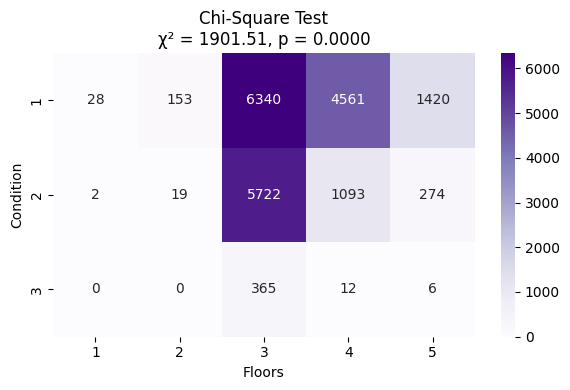

In [47]:
# Contingency table
contingency = pd.crosstab(df['floors'], df['condition'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Chi-square visualization
plt.figure(figsize=(6,4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Floors')
plt.ylabel('Condition')
plt.title(f'Chi-Square Test\nχ² = {chi2:.2f}, p = {p:.4f}')
plt.tight_layout()
plt.savefig("CHi-Square Test Visualization.png", dpi=1000)
plt.show()
